In [1]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import joblib

In [3]:
df = pd.read_csv("../datasets/synthetic_expense_categories.csv")

print(df.shape)
print(df.isnull().sum())
print(df["Label"].value_counts())
df.head()

(11655, 2)
Transaction_Text    0
Label               0
dtype: int64
Label
Travel             738
Shopping           714
Entertainment      713
Gifts_Donations    691
Healthcare         686
Transport          670
Food               663
Fitness            660
Personal_Care      652
Utilities          637
Miscellaneous      636
Groceries          633
Subscription       630
Education          624
Insurance          617
Investment         575
EMI                559
Rent               557
Name: count, dtype: int64


,Transaction_Text,Label
0,Debit card spend at Gas Cylinder Booking,Utilities
1,"Two Wheeler Loan monthly charge - INR 18,747.72",EMI
2,Health Insurance Premium - Star order #463921,Insurance
3,Amazon Fresh - 2024-05-18,Groceries
4,"Auto-debit Bike Insurance Renewal - INR 15,046.26",Insurance


In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["Transaction_Text"].apply(clean_text)
df[["Transaction_Text", "clean_text"]].head()

,Transaction_Text,clean_text
0,Debit card spend at Gas Cylinder Booking,debit card spend at gas cylinder booking
1,"Two Wheeler Loan monthly charge - INR 18,747.72","two wheeler loan monthly charge - inr 18,747.72"
2,Health Insurance Premium - Star order #463921,health insurance premium - star order #463921
3,Amazon Fresh - 2024-05-18,amazon fresh - 2024-05-18
4,"Auto-debit Bike Insurance Renewal - INR 15,046.26","auto-debit bike insurance renewal - inr 15,046.26"


In [5]:
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["Label"])

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label_enc"],
    test_size=0.2, random_state=42, stratify=df["label_enc"]
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 9324 | Test size: 2331


In [6]:
vectorizer = TfidfVectorizer(max_features=4000, ngram_range=(1, 2))

X_train_vec = vectorizer.fit_transform(X_train)   # fit ONLY on train
X_test_vec = vectorizer.transform(X_test)          # transform test

print(X_train_vec.shape, X_test_vec.shape)

(9324, 4000) (2331, 4000)


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, eval_metric="mlogloss", random_state=42),
}

trained = {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    trained[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Random Forest trained.
XGBoost trained.


In [8]:
results = []
for name, model in trained.items():
    preds = model.predict(X_test_vec)
    acc = accuracy_score(y_test, preds)
    results.append({"Model": name, "Accuracy": round(acc, 4)})
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds, target_names=le.classes_))

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df


=== Logistic Regression ===
                 precision    recall  f1-score   support

            EMI       0.98      0.90      0.94       112
      Education       0.98      0.94      0.96       125
  Entertainment       0.86      0.95      0.90       143
        Fitness       0.94      0.91      0.93       132
           Food       0.75      0.92      0.82       133
Gifts_Donations       0.91      0.95      0.93       138
      Groceries       0.89      0.95      0.92       127
     Healthcare       0.96      0.93      0.94       137
      Insurance       0.98      0.91      0.95       123
     Investment       0.94      0.90      0.92       115
  Miscellaneous       0.96      0.92      0.94       127
  Personal_Care       0.98      0.92      0.95       130
           Rent       0.96      0.90      0.93       111
       Shopping       0.94      0.95      0.95       143
   Subscription       0.96      0.95      0.96       126
      Transport       0.93      0.93      0.93       134
 

,Model,Accuracy
0,Logistic Regression,0.9271
1,Random Forest,0.9215
2,XGBoost,0.9142


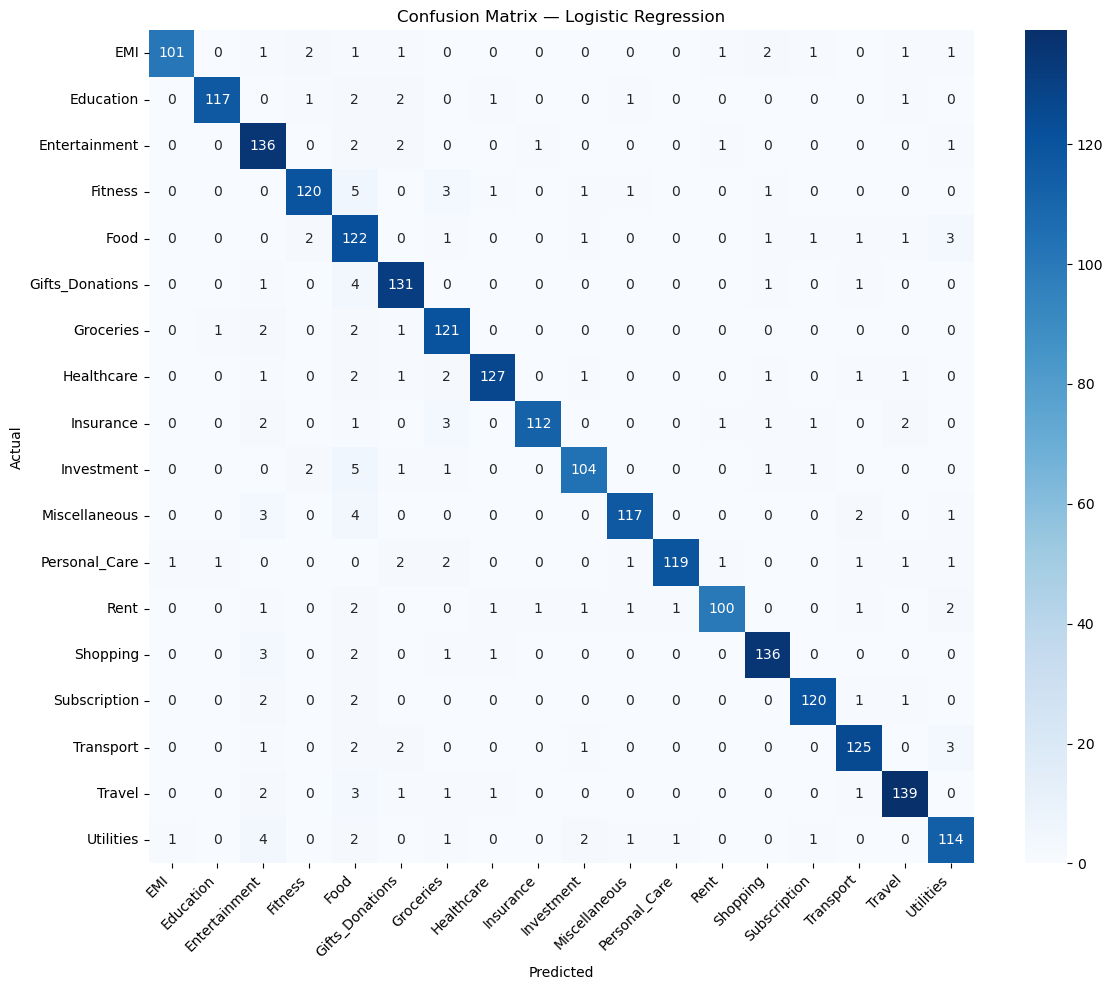

In [9]:
best_name = results_df.iloc[0]["Model"]
best_model = trained[best_name]
preds = best_model.predict(X_test_vec)

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
joblib.dump(best_model, "expense_category_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(le, "label_encoder.pkl")

print(f"Saved {best_name} as the production model.")

Saved Logistic Regression as the production model.


In [11]:
def predict_category(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = best_model.predict(vec)
    return le.inverse_transform(pred)[0]

print(predict_category("Swiggy order - INR 450"))
print(predict_category("HDFC Home Loan EMI - INR 25000"))
print(predict_category("Netflix Subscription - INR 649"))

Food
EMI
Entertainment
